# **CSI 4106 Introduction to Artificial Intelligence**
## **Assignment 4: Heuristic Search**

### Identification

Name: Kanjanokphat Kitisuwanakul <br/>
Student Number: 300170040

Name: Kien Do <br/>
Student Number: 300163370

<br/>
<hr/>

## **Overview**

The **Traveling Salesman Problem (TSP)** is a classic optimization problem in computer science and operations research. Given a set of cities and the distances between them, the goal is to find the shortest possible route that visits each city exactly once and returns to the starting city. Despite its simple formulation, solving TSP is computationally challenging because the number of possible routes grows factorially with the number of cities.

TSP is classified as an NP-hard problem, meaning there is no known efficient algorithm to solve it optimally for large instances. This complexity, combined with its practical importance in fields like logistics, manufacturing, and circuit design, has made TSP a benchmark problem for evaluating optimization algorithms.

In this assignment, you will explore three different approaches to tackling TSP:

- **Greedy Algorithm**: A heuristic method that builds a solution incrementally by choosing locally optimal decisions.
- **Simulated Annealing (SA)**: A probabilistic algorithm inspired by the annealing process in metallurgy.
- **Genetic Algorithm (GA)**: An evolutionary algorithm that mimics natural selection to iteratively improve solutions.

The final deliverable for this assignment will be a Jupyter Notebook documenting your implementation, results, and observations for each approach.

## **Learning Objectives**

- **Explore** and **implement** different search-based algorithms.
- **Develop** a Simulated Annealing algorithm with an effective strategy for setting the initial temperature.
- **Adapt** and **apply** a Genetic Algorithm for solving the TSP.
- **Analyze** and **evaluate** the performance of each algorithm against known optimal solutions.

## Submission

- **Deadline:**
   - Submit your notebook by December 4, 11 PM.
- **Individual or Group Assignment:**
   - This assignment may be undertaken either individually (group of 1 student) or collaboratively in pairs (group of 2 students)
   - A group must submit a single joint submission.
   - Prior to submitting, it is necessary to **register your group** on Brightspace.
- **Submission Platform:**
   - Upload your submission to Brightspace under the Assignment section (Assignment 4).
- **Submission Format:**
   - Submit a copy of your notebook on Brightspace.

**Important Notice:** If the corrector cannot run your code, your submission will receive a mark of zero. It is your responsibility to ensure that your submission works from a different computer than your own and that all cells in your notebook are executable.

## **Datasets**

The datasets utilized in this assignment are sourced from the [TSPLIB GitHub Repository](https://github.com/mastqe/tsplib), which provides standard benchmark instances for the Traveling Salesman Problem (TSP). These datasets are defined as **Euclidean**, meaning that the distance between any two cities is calculated using the Euclidean metric based on their coordinates.

For your tests, you will employ the **berlin52-24-4** and **st70-24** datasets. Each of these is a subset consisting of 24 cities from the respective problems. The lower bound on cost for these instances has been determined using dynamic programming, specifically the Held-Karp algorithm.

1. **berlin52-24-4**:
   - Number of Cities: 24
   - Optimal Solution Cost: **5890.92**

2. **st70-24-4**:
   - Number of Cities: 24
   - Optimal Solution Cost: **468.88**

These datasets are intended for evaluating the performance of your algorithms, enabling you to compare your results with established optimal solutions. The data is accessible on GitHub at the following link: [here](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a4). Additionally, the `extra` subfolder contains supplementary problems that may assist you in completing this assignment.

For the optional bonus question, you will work with the following two datasets:

3. **berlin52**:
   - Number of Cities: 52
   - Description: A medium-sized dataset with realistic spatial distribution of cities.
   - Optimal Solution Cost: **7542**

4. **st70**:
   - Number of Cities: 70
   - Description: A slightly larger dataset with increased complexity.
   - Optimal Solution Cost: **675**

<br>
<hr/>

## **0. Given Code**

Here is a Jupyter Notebook featuring greedy algorithms and a genetic algorithm for solving the 0/1 knapsack problem.

<a target="_blank" href="https://colab.research.google.com/github/turcotte/csi4106-f24/blob/main/notebooks/lectures/16/knapsack.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

The following two lectures may be useful for this assignment.

- [Lecture 15](https://turcotte.xyz/teaching/csi-4106/lectures/15/slides.html) (simulated annealing)
- [Lecture 16](https://turcotte.xyz/teaching/csi-4106/lectures/16/slides.html) (genetic algorithm)

### 0.1. Imports

In [ ]:
# Imports needed for the assignment go here:

import numpy as np
import pandas as pd
import requests
import math
import time

### 0.2. Read the TSP Files

A function to read TSP files from a website.

In [ ]:
def read_tsp(url):

    """
    Reads a .tsp file from a given URL and returns a NumPy array of coordinates.

    Parameters:
    -----------
    url : str
        The URL of the .tsp file.

    Returns:
    --------
    coordinates : ndarray
        A NumPy array of coordinates extracted from the .tsp file.

    Description:
    ------------
    This function fetches the content of a .tsp file from a specified URL and parses it to extract the city coordinates.
    It looks for the 'NODE_COORD_SECTION' in the file to start reading coordinates and stops when it reaches 'EOF'.
    The function handles potential errors by checking the HTTP response status and ensures that the coordinates are
    correctly parsed into floating-point numbers.

    Example:
    --------
    >>> url = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/main/assignments-data/a4/berlin52-24-4.tsp'
    >>> coordinates = read_tsp(url)
    >>> print(coordinates)
    [[37.7692, -122.4443],
     [37.7689, -122.4240],
     ...
     [37.7793, -122.4192]]
    """

    try:
        # Fetch the content from the URL
        response = requests.get(url)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

        # Split the content into lines
        lines = response.text.splitlines()

        # Initialize a list to store the coordinates
        coordinates = []

        # Start reading after the NODE_COORD_SECTION line
        node_section = False
        for line in lines:
            line = line.strip()
            if line == "NODE_COORD_SECTION":
                node_section = True
                continue
            elif line == "EOF":
                break

            if node_section:
                # Split the line into parts and convert to float
                parts = line.split()
                if len(parts) >= 3:
                    # Some files include node indices, so we take the last two entries as coordinates
                    x, y = float(parts[-2]), float(parts[-1])
                    coordinates.append((x, y))

        # Convert the list of coordinates to a NumPy array
        return np.array(coordinates)

    except requests.exceptions.RequestException as e:
        print(f"An error occurred while fetching the TSP file: {e}")
        return None
    except ValueError as e:
        print(f"An error occurred while parsing the coordinates: {e}")
        return None

In [ ]:
URL = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/main/assignments-data/a4/'

berlin52_24_4 = read_tsp(URL + 'berlin52-24-4.tsp')
st70_24_4 = read_tsp(URL + 'st70-24-4.tsp')

The following function accepts the coordinates of the cities as input and outputs a distance matrix.

In [ ]:
def get_distance_matrix(coordinates):

    """
        Takes coordinates input and returns distance matrix
        Input: coordinates (nn.array) - the input coordinates
        Output: distance_matrix (np.array) - the (num_cities x num_cities) distance matrix
    """

    num_cities = len(coordinates)
    distance_matrix = np.zeros((num_cities, num_cities))

    for i in range(num_cities):
        for j in range(num_cities):
            distance_matrix[i][j] = np.linalg.norm(coordinates[i] - coordinates[j])

    return distance_matrix

Get the distance matrix from each dataset

In [ ]:
# Berlin dataset
distance_matrix_berlin = get_distance_matrix(berlin52_24_4)

# St dataset
distance_matrix_st = get_distance_matrix(st70_24_4)

The following functions may assist in visualizing results and debugging your programs.

In [ ]:
import matplotlib.pyplot as plt

def plot_cities(coordinates, title="Cities in the Traveling Salesman Problem"):

    """
    Plots the given coordinates representing cities.

    Parameters:
    - coordinates: A 2D NumPy array of shape (n, 2) representing the (x, y) coordinates.
    - title: Title for the plot.
    """

    # Extract x and y coordinates
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # Plot the cities as red dots
    plt.scatter(x, y, c='red', zorder=2)

    # Annotate the cities with their indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Set title and labels
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.axis('equal')  # Equal scaling for x and y axes
    plt.show()

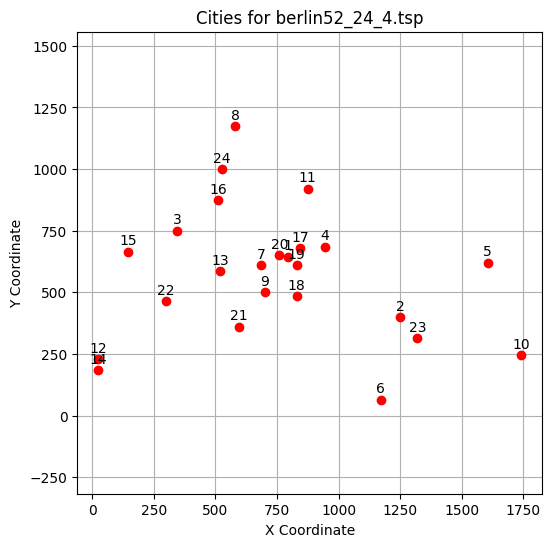

In [ ]:
plot_cities(berlin52_24_4, title='Cities for berlin52_24_4.tsp')

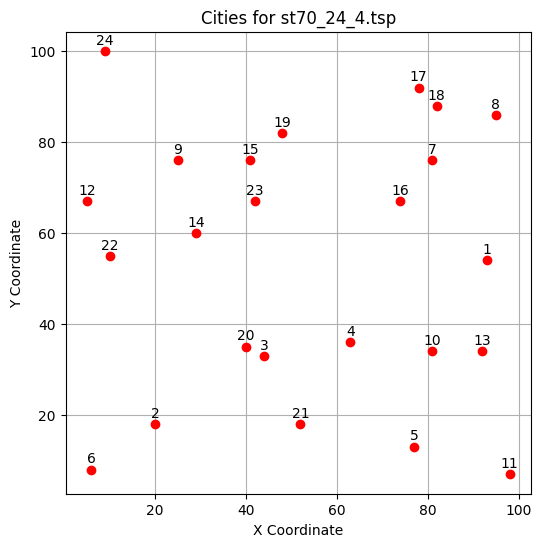

In [ ]:
plot_cities(st70_24_4, title='Cities for st70_24_4.tsp')

In [ ]:
def plot_tsp_path(coordinates, path=None, title="Traveling Salesman Problem"):

    """
    Plots the given coordinates and optionally a path for the TSP.

    Parameters:
    - coordinates: A 2D NumPy array of shape (n, 2) representing the (x, y) coordinates.
    - path: A list or array of indices representing the order of visiting the nodes. If None, nodes are connected in input order.
    - title: Title for the plot.
    """

    # Extract x and y coordinates
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # If a path is given, reorder the coordinates
    if path is not None:
        x = x[path]
        y = y[path]

    # Plot the nodes
    plt.scatter(x, y, c='red', zorder=2)

    # Annotate the nodes with their indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Plot the path
    plt.plot(x, y, 'b-', zorder=1)

    # If a path is provided, connect the last point to the first to complete the tour
    if path is not None:
        plt.plot([x[-1], x[0]], [y[-1], y[0]], 'b-', zorder=1)

    # Set title and labels
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.axis('equal')  # Equal scaling for x and y axes
    plt.show()

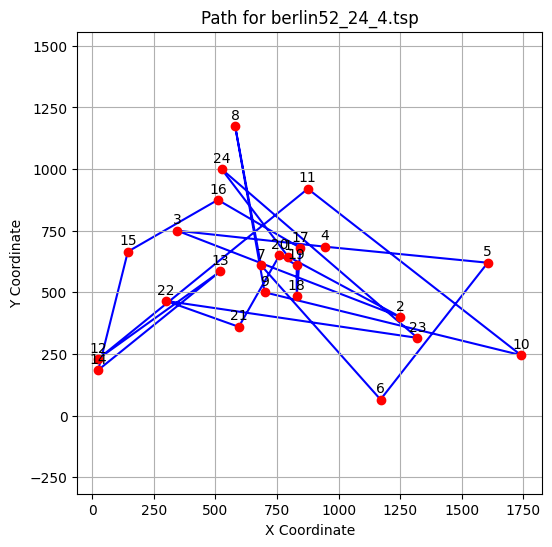

In [ ]:
plot_tsp_path(berlin52_24_4, path=np.arange(len(berlin52_24_4)), title='Path for berlin52_24_4.tsp')

<hr/>

## 1. Implement the Algorithms

### 1.1. Implement a solver for the TSP using Greedy Algorithm

The **nearest neighbor heuristic** is a greedy algorithm used to find a feasible solution to the Traveling Salesman Problem (TSP).
- The process begins by selecting a starting city and iteratively visiting the nearest unvisited city until all cities are visited. The tour is completed by returning to the starting point.
- This procedure is repeated for each city as the initial starting point, and the shortest resulting tour is selected.
- The algorithm strictly evaluates only valid routes, ensuring each city is visited exactly once.
- While this approach efficiently constructs a feasible TSP solution, it does not ensure an optimal solution.

### **Understanding the inputs** ✅

In [ ]:
# berlin dataset with 24 cities
print(len(berlin52_24_4))
print(berlin52_24_4)

24
[[ 795.  645.]
 [1250.  400.]
 [ 345.  750.]
 [ 945.  685.]
 [1605.  620.]
 [1170.   65.]
 [ 685.  610.]
 [ 580. 1175.]
 [ 700.  500.]
 [1740.  245.]
 [ 875.  920.]
 [  25.  230.]
 [ 520.  585.]
 [  25.  185.]
 [ 145.  665.]
 [ 510.  875.]
 [ 845.  680.]
 [ 830.  485.]
 [ 830.  610.]
 [ 760.  650.]
 [ 595.  360.]
 [ 300.  465.]
 [1320.  315.]
 [ 525. 1000.]]


In [ ]:
# st dataset with 24 cities
print(len(st70_24_4))
print(st70_24_4)

24
[[ 93.  54.]
 [ 20.  18.]
 [ 44.  33.]
 [ 63.  36.]
 [ 77.  13.]
 [  6.   8.]
 [ 81.  76.]
 [ 95.  86.]
 [ 25.  76.]
 [ 81.  34.]
 [ 98.   7.]
 [  5.  67.]
 [ 92.  34.]
 [ 29.  60.]
 [ 41.  76.]
 [ 74.  67.]
 [ 78.  92.]
 [ 82.  88.]
 [ 48.  82.]
 [ 40.  35.]
 [ 52.  18.]
 [ 10.  55.]
 [ 42.  67.]
 [  9. 100.]]


Distance matrix[i] shows the distance from city i.

For example:
```
[[ 0.          7.07106781 28.28427125]  # Distances from City 0
[ 7.07106781  0.         21.21320344]  # Distances from City 1
[28.28427125 21.21320344  0.        ]]  # Distances from City 2
 ```

Entry 0 is zero because distance of city 0 to itself is zero.


In [ ]:
# Berlin dataset
distance_matrix_berlin = get_distance_matrix(berlin52_24_4)
print(distance_matrix_berlin[0]) # means distances of each city from city zero

[   0.          516.76880711  462.08765402  155.24174696  810.38571063
  690.6699646   115.43396381  571.94842425  173.34935823 1026.17006388
  286.40006983  874.71423905  281.4693589   896.93923986  650.30761952
  366.23080154   61.03277808  163.78339354   49.49747468   35.35533906
  348.17380717  526.71149598  620.10079826  446.01008957]


In [ ]:
# St dataset
distance_matrix_st = get_distance_matrix(st70_24_4)
print(distance_matrix_st[0]) # means distances of each city from city zero

[ 0.         81.39410298 53.31041174 34.98571137 44.01136217 98.41239759
 25.05992817 32.06243908 71.47027354 23.32380758 47.26520919 88.95504483
 20.02498439 64.28063472 56.46237685 23.02172887 40.85339643 35.73513677
 53.         56.30275304 54.56189146 83.00602388 52.63078947 95.77055915]


### **Greedy TSP implementation** ✅

In [ ]:

def greedy_tsp(city, distance_matrix):
  """
  Greedy TSP solution that calculates the shortest cycle starting from any city
  Parameters: city coordinates dataset and distance matrix
  Returns: The coordinates of shortest cycle in numpy array
  """

  tsp_distance = float('inf') # best distance of the paths
  result = [] # best paths from each city

  # select each starting city one by one
  for i in range(len(city)):

    # a set to keep track of visited cities
    visited = set()

    # get coordinates of this city
    current_city = i
    # print("Processing city ", current_city, "with coordinates", city[i])

    # this cycle starts with the current city
    cycle = [current_city]

    # distance for this city
    distance = 0

    while len(visited) < len(city):

      # this city is being visited
      visited.add(current_city)

      # get distance from this city, use copy() because of np array references
      distance_from_visiting = distance_matrix[current_city].copy()

      # set the visited cities to infinity and ignore them
      for v in visited:
        distance_from_visiting[v] = float('inf')

      # get the index of the min next distance
      closest_city_index = np.argmin(distance_from_visiting)

      # If closest_city_index is inf (no more unvisited cities), break the loop
      if distance_from_visiting[closest_city_index] == float('inf'):
          break

      # add the distance
      distance += distance_from_visiting[closest_city_index]

      # add this city to the path
      cycle.append(closest_city_index)

      # the next city is the one at min index
      current_city = closest_city_index

    # when all cities have been visited, return to city i
    distance += distance_matrix[current_city][i]
    cycle.append(i)

    # get the best path amongst all starting cities
    if distance < tsp_distance:
      tsp_distance = distance
      result = cycle

  return result, tsp_distance


**Run on Berlin Dataset**✅

In [ ]:
path, dist = greedy_tsp(berlin52_24_4, distance_matrix_berlin)

print("Shortest path: ", path)
print("Shortest distance: ", dist)

Shortest path:  [20, 8, 6, 19, 0, 18, 16, 3, 17, 12, 2, 15, 23, 7, 10, 1, 22, 5, 9, 4, 21, 14, 11, 13, 20]
Shortest distance:  7029.605933260265


In [ ]:
# Reorder the coordinates based on the path
ordered_coordinates = berlin52_24_4[path]
print("Ordered coordinates:", ordered_coordinates)

Ordered coordinates: [[ 595.  360.]
 [ 700.  500.]
 [ 685.  610.]
 [ 760.  650.]
 [ 795.  645.]
 [ 830.  610.]
 [ 845.  680.]
 [ 945.  685.]
 [ 830.  485.]
 [ 520.  585.]
 [ 345.  750.]
 [ 510.  875.]
 [ 525. 1000.]
 [ 580. 1175.]
 [ 875.  920.]
 [1250.  400.]
 [1320.  315.]
 [1170.   65.]
 [1740.  245.]
 [1605.  620.]
 [ 300.  465.]
 [ 145.  665.]
 [  25.  230.]
 [  25.  185.]
 [ 595.  360.]]


In [ ]:
print(path)

[20, 8, 6, 19, 0, 18, 16, 3, 17, 12, 2, 15, 23, 7, 10, 1, 22, 5, 9, 4, 21, 14, 11, 13, 20]


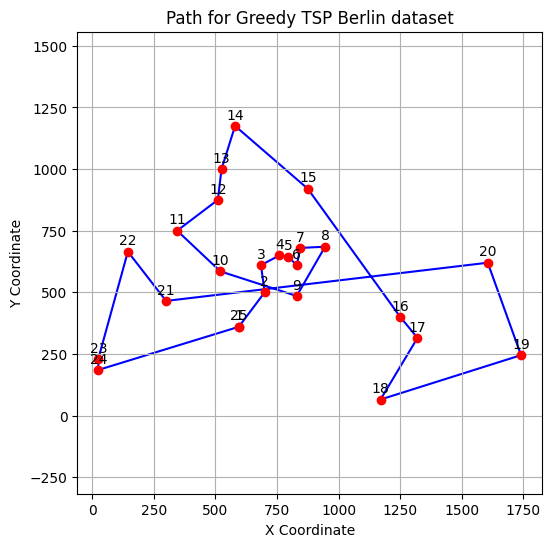

In [ ]:
# Visualize the path for Berlin dataset
plot_tsp_path(ordered_coordinates, path=np.arange(len(ordered_coordinates)), title='Path for Greedy TSP Berlin dataset')

**Run on ST Dataset** ✅

In [ ]:
path2, dist2 = greedy_tsp(st70_24_4, distance_matrix_st)

print("Shortest path: ", path2)
print("Shortest distance: ", dist2)

Shortest path:  [8, 14, 22, 13, 21, 11, 23, 18, 15, 6, 17, 16, 7, 0, 12, 9, 3, 2, 19, 20, 4, 10, 1, 5, 8]
Shortest distance:  565.4375142594132


In [ ]:
# Reorder the coordinates based on the path
ordered_coordinates2 = st70_24_4[path2]
print("Ordered coordinates:", ordered_coordinates2)

Ordered coordinates: [[ 25.  76.]
 [ 41.  76.]
 [ 42.  67.]
 [ 29.  60.]
 [ 10.  55.]
 [  5.  67.]
 [  9. 100.]
 [ 48.  82.]
 [ 74.  67.]
 [ 81.  76.]
 [ 82.  88.]
 [ 78.  92.]
 [ 95.  86.]
 [ 93.  54.]
 [ 92.  34.]
 [ 81.  34.]
 [ 63.  36.]
 [ 44.  33.]
 [ 40.  35.]
 [ 52.  18.]
 [ 77.  13.]
 [ 98.   7.]
 [ 20.  18.]
 [  6.   8.]
 [ 25.  76.]]


In [ ]:
print(path2)

[8, 14, 22, 13, 21, 11, 23, 18, 15, 6, 17, 16, 7, 0, 12, 9, 3, 2, 19, 20, 4, 10, 1, 5, 8]


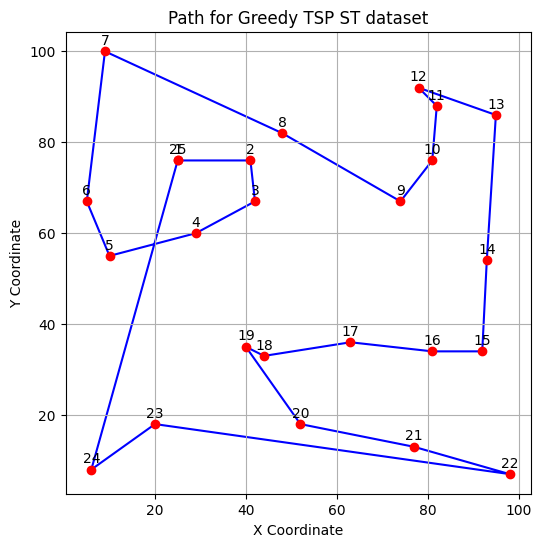

In [ ]:
# Visualize the path for ST dataset
plot_tsp_path(ordered_coordinates2, path=np.arange(len(ordered_coordinates2)), title='Path for Greedy TSP ST dataset')

### 1.2. Implement a solver for the TSP using Simulated Annealing

For the implementation of Simulated Annealing (SA) algorithm below, **implement a strategy to determine the initial temperature for the search**.

**Suggestions**:
- Calculate the cost of a random tour and set an initial temperature such that the acceptance rate of new solutions is between 60% and 80%. **[Chosen strategy]** ✅
- Alternatively, perform a few preliminary iterations of the SA algorithm, gradually reducing the temperature until the acceptance rate achieves the desired range of 60% to 80%. Then, restart with this temperature.

Specifically, you need to finalize the implementation of the `get_initial_temperature` method below.

In [ ]:
def calculate_total_distance(route, distance_matrix):

    """
    Calculate the total distance of a given route based on the distance matrix.

    Parameters:
    -----------
    route : ndarray
        An array representing the order of cities in the route (a permutation of city indices).
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.

    Returns:
    --------
    total_distance : float
        The total distance of the route, including the return to the starting city.

    Description:
    ------------
    The function computes the sum of distances between consecutive cities in the route
    and adds the distance from the last city back to the first city to complete the tour.
    It assumes that the distance matrix is symmetric and non-negative.
    """

    total_distance = 0

    for i in range(len(route) - 1):
        total_distance += distance_matrix[route[i], route[i + 1]]

    total_distance += distance_matrix[route[-1], route[0]]  # Back to start

    return total_distance

In [ ]:
def get_neighbor(route):

    """
    Generate a neighboring solution by reversing a random segment of the route.

    Parameters:
    -----------
    route : ndarray
        An array representing the current route (a permutation of city indices).

    Returns:
    --------
    new_route : ndarray
        A new route obtained by reversing the segment between two randomly chosen indices.

    Description:
    ------------
    This method selects two random indices, `a` and `b`, within the route and reverses the
    segment between them (inclusive). It is commonly used in optimization algorithms like
    Simulated Annealing to explore neighboring solutions in the search space.
    """

    a, b = np.random.randint(0, len(route), size=2)

    if a > b:
        a, b = b, a

    new_route = route.copy()
    new_route[a:b+1] = new_route[a:b+1][::-1]  # Reverse the segment between a and b

    return new_route

Finalize the implementation of the `get_initial_temperature` method. You may introduce additional parameters to the function definition as needed; ensure that any modifications are consistently reflected in all methods that invoke this function.

**Get initial temperature implementation** ✅

The chosen strategy to obtain the initial temperature is as follows:

1. The probability of acceptance of results is based on the following formula:
`probability_acceptance = exp(-delta_e / temperature)`

2. Since we want a probability of acceptance of around 60-80%, we can manipulate the formula to make temperature subject of formula as such:
`Temperature = (-delta_e) / ln (probability_acceptance)`

3. We will choose a probability_acceptance of **70%** for this experiment.

4. Calculate the differences between costs of random neighbours and the current cost, this represents the `delta_e`.

5. We get `delta_e` for **n neighbours**(choose n = 100 here) and save the differences in an array `delta_e[]`

6. When done, get the average cost difference of all these n iterations.

7. Now use this final value of `delta_e` in the formula to obtain the `initial_temperature`

In [ ]:
def get_initial_temperature(distance_matrix):

    """
    Estimate an initial temperature for the Simulated Annealing algorithm.

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.

    Returns:
    --------
    initial_temp : float
        The estimated initial temperature to achieve the specified acceptance rate.

    Description:
    ------------
    The function:
        - Complete this section
    """

    num_iterations = 100 # how many iterations to do average on
    delta_e = []
    acceptance_prob = 0.70 # 60% to 80%

    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)

    best_route = current_route.copy()
    best_cost = current_cost

    for iteration in range(num_iterations):

        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)

        # find absolute value of difference
        diff = abs(neighbor_cost - current_cost)

        #print(f"Energy lost for this iteration {iteration} is {diff}")

        # Add the delta E in an array
        delta_e.append(diff)

    delta_e_avg = np.mean(delta_e)
    #print("Average energy lost is:", delta_e_avg)

    # use formula to calculate temp
    # Temp = -delta_e / ln(acceptance probabiliity)

    initial_temp = -delta_e_avg / np.log(acceptance_prob)

    return initial_temp

In [ ]:
# Test get initial temp
initial_temp = get_initial_temperature(distance_matrix_berlin)
print("Initial temperature must be:", initial_temp)

Average energy lost is: 279.7271952955035
Initial temperature must be: 784.2636553229638


**Simulated Annealing Implementation**

In [ ]:
def simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations):

    """
    Perform the Simulated Annealing algorithm to approximate a solution for the Traveling Salesman Problem (TSP).

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    initial_temp : float
        The initial temperature for the annealing process.
    cooling_rate : float
        The rate at which the temperature decreases, typically a value between 0 and 1.
    max_iterations : int
        The maximum number of iterations to perform.

    Returns:
    --------
    best_route : ndarray
        The order of cities in the best (shortest) route found.
    best_cost : float
        The total distance of the best route.
    temperatures : list
        A list of temperature values at each iteration, useful for analysis or plotting.
    costs : list
        A list of route costs (distances) at each iteration, useful for analysis or plotting.

    Description:
    ------------
    Simulated Annealing (SA) is a probabilistic optimization algorithm inspired by the annealing process in metallurgy.
    This implementation:
    - Starts with a random route and iteratively improves it.
    - Accepts worse solutions with a probability dependent on the temperature to escape local minima.
    - Reduces the temperature gradually to focus on exploitation as the algorithm progresses.
    - Returns the best route found along with intermediate data for analysis.

    """

    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)

    best_route = current_route.copy()
    best_cost = current_cost

    temperatures = []
    costs = []

    temperature = initial_temp

    # Collect intermediate solutions
    intermediate_solutions = []

    for iteration in range(max_iterations):

        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)

        # Accept neighbor if it's better, or with a probability if it's worse
        if neighbor_cost < current_cost or np.random.rand() < np.exp(-(neighbor_cost - current_cost) / temperature):
            current_route = neighbor_route
            current_cost = neighbor_cost

            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost

        # Store temperature and cost for plotting
        temperatures.append(temperature)
        costs.append(current_cost)

        # Cool down the temperature
        temperature *= cooling_rate

    return best_route, best_cost, temperatures, costs

In [ ]:
def simulated_annealing_do_n(distance_matrix, initial_temp, cooling_rate=0.995, max_iterations=1000, repeats=20):

    """
    Perform Simulated Annealing multiple times and return the best result across all runs.

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    initial_temp : float
        The initial temperature for the annealing process.
    cooling_rate : float
        The rate at which the temperature decreases, typically a value between 0 and 1.
    max_iterations : int
        The maximum number of iterations for each Simulated Annealing run.
    repeats : int
        The number of times to repeat the Simulated Annealing process.

    Returns:
    --------
    best_tour : ndarray
        The order of cities in the best (shortest) tour found across all runs.
    best_distance : float
        The total distance of the best tour.
    best_temperatures : list
        A list of temperature values from the best run, useful for analysis or plotting.
    best_costs : list
        A list of route costs (distances) from the best run, useful for analysis or plotting.

    Notes:
    ------
    This method leverages the `simulated_annealing` function to perform individual optimization runs.
    By repeating the process multiple times, it increases the likelihood of finding a globally optimal or near-optimal solution.
    """

    results = [
        simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations)
        for _ in range(repeats)
    ]

    # Find the best result by minimizing the distance
    best_tour, best_distance, best_temperatures, best_costs = min(results, key=lambda x: x[1])

    return best_tour, best_distance, best_temperatures, best_costs

The following functions may assist in visualizing results and debugging your programs.

In [ ]:
def plot_temperature_and_cost(temperatures, costs):

    """
    Plot the temperature and cost values over iterations in a side-by-side graph.

    Parameters:
    -----------
    temperatures : list or ndarray
        A sequence of temperature values recorded at each iteration of an algorithm (e.g., Simulated Annealing).
    costs : list or ndarray
        A sequence of cost values (e.g., total distance or energy) recorded at each iteration.

    Description:
    ------------
    This function generates two subplots:
    1. **Temperature Over Iterations**: Plots how the temperature changes over time, which is useful for visualizing the cooling schedule in algorithms like Simulated Annealing.
    2. **Cost Over Iterations**: Plots the cost (e.g., total distance in TSP) at each iteration, showing how the solution improves over time.

    The plots are arranged side by side for easy comparison between the temperature schedule and the corresponding cost progression. The function adjusts the layout for better spacing and displays the combined figure.

    Example:
    --------
    >>> plot_temperature_and_cost(temperatures, costs)

    Notes:
    ------
    - Ensure that the lengths of `temperatures` and `costs` are equal, corresponding to the number of iterations.
    - Requires `matplotlib.pyplot` as `plt` to be imported before calling this function.
    """

    # Plot temperature and cost graphs
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(temperatures)
    plt.title("Temperature Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Temperature")

    plt.subplot(1, 2, 2)
    plt.plot(costs)
    plt.title("Cost Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")

    plt.tight_layout()
    plt.show()

### 1.3. Implement a solver for the TSP using Genetic Algorithm

You will find below a partial implementation of a **Genetic Algorithm (GA)** to find an approximate solution to the TSP.

The main steps of the algorithm are:

1. **Initialization**: Create a random initial population of routes.
2. **Evaluation**: Compute the fitness of individuals based on their route distances. (partial implementation)
3. **Elitism**: Preserve the top-performing individuals for the next generation.
4. **Selection**: Choose parents using tournament or roulette wheel selection.
5. **Crossover**: Generate offspring by combining parents using a crossover operator. (partial implementation)
6. **Mutation**: Introduce diversity by randomly mutating offspring. (partial implementation)
7. **Replacement**: Combine elites and offspring to form the next generation.
8. Repeat steps 2-7 for a fixed number of generations, tracking the best and average distances.

Ensure that all generated solutions are valid tours, with each city visited exactly once.

Specifically, you must implement `evaluate_fitness`, `crossover_operator`, `mutation`.

In [ ]:
def initialize_population(pop_size, num_cities):

    """
    Generate an initial population of random routes for a Genetic Algorithm.

    Parameters:
    -----------
    pop_size : int
        The number of individuals (routes) in the population.
    num_cities : int
        The number of cities in the Traveling Salesman Problem (TSP).

    Returns:
    --------
    population : ndarray
        A 2D array of shape (pop_size, num_cities), where each row represents
        a random permutation of city indices (a potential solution).

    Description:
    ------------
    This function initializes a population by creating `pop_size` random permutations
    of city indices, ensuring diversity in the initial solutions. Each individual
    represents a valid route for the TSP.
    """

    return np.array([np.random.permutation(num_cities) for _ in range(pop_size)])

Finalize the implementation of the `evaluate_fitness` method.

**Evaluate fitness method** ✅

In [ ]:
def evaluate_fitness(population, distance_matrix):

    """
    Evaluate the fitness of each individual in a population for a Genetic Algorithm.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row is an individual route (a permutation of city indices).
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.

    Returns:
    --------
    fitness : ndarray
        A 1D array containing the fitness values for each individual in the population.
        Fitness is calculated as the reciprocal of the total distance of the route.
    total_distances : ndarray
        A 1D array containing the total distances of the routes for each individual.

    Description:
    ------------
    This function calculates:
    1. The total distance of each individual's route by summing the distances between consecutive cities,
       including the return to the starting city.
    2. The fitness value for each individual as the reciprocal of its total distance
       (with a small constant added to avoid division by zero).

    Fitness values are higher for shorter routes, encouraging better solutions during selection.
    """

    fitness = []
    total_distances = []

    for route in population:
        total_distance = calculate_total_distance(route, distance_matrix)
        fitness.append(1 / (total_distance + 1e-6))  # Small constant to avoid division by zero
        total_distances.append(total_distance)

    return np.array(fitness), np.array(total_distances)

In [ ]:
def tournament_selection(population, fitness, tournament_size):

    """
    Perform tournament selection to choose individuals for the next generation in a Genetic Algorithm.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row represents an individual (a potential solution).
    fitness : ndarray
        A 1D array containing the fitness values of the individuals in the population.
    tournament_size : int
        The number of individuals randomly selected for each tournament.

    Returns:
    --------
    selected_population : ndarray
        A 2D array of the same shape as `population`, containing the selected individuals
        for the next generation.

    Description:
    ------------
    Tournament selection works as follows:
    1. For each individual to be selected, randomly choose `tournament_size` participants from the population.
    2. Compare their fitness values and select the individual with the highest fitness.
    3. Repeat this process until a new population of the same size as the original is formed.

    This method balances exploitation (choosing the best individuals) with exploration (random selection
    of participants), allowing the algorithm to focus on high-quality solutions while maintaining diversity.
    """

    pop_size = population.shape[0]
    selected_indices = []

    for _ in range(pop_size):

        participants = np.random.choice(pop_size, tournament_size, replace=False)
        best = participants[np.argmax(fitness[participants])]
        selected_indices.append(best)

    return population[selected_indices]

In [ ]:
def roulette_selection(population, fitness):

    """
    Perform roulette wheel selection to choose individuals for the next generation in a Genetic Algorithm.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row represents an individual (a potential solution).
    fitness : ndarray
        A 1D array containing the fitness values of the individuals in the population.

    Returns:
    --------
    selected_population : ndarray
        A 2D array of the same shape as `population`, containing the selected individuals
        for the next generation.

    Description:
    ------------
    Roulette wheel selection assigns selection probabilities to individuals based on their fitness:
    1. Compute the total fitness of the population.
    2. Normalize fitness values to create probabilities for each individual.
    3. Randomly select individuals from the population according to their probabilities.

    This method favors individuals with higher fitness, increasing their likelihood of being selected,
    while still allowing lower-fitness individuals a chance, maintaining genetic diversity.
    """

    total_fitness = np.sum(fitness)
    probabilities = fitness / total_fitness
    pop_size = population.shape[0]
    selected_indices = np.random.choice(pop_size, size=pop_size, p=probabilities)

    return population[selected_indices]

Finalize the implementation of the `crossover_operator` method. ✅

In [ ]:
def crossover_operator(parent1, parent2):

    """
    Perform crossover to produce an offspring from two parent solutions.

    Parameters:
    -----------
    parent1 : ndarray
        A 1D array representing the first parent (a permutation of city indices).
    parent2 : ndarray
        A 1D array representing the second parent (a permutation of city indices).

    Returns:
    --------
    child : ndarray
        A 1D array representing the offspring, combining genetic material from both parents.

    Description:
    ------------
        This function implements the Order Crossover (OX) technique for generating an offspring from two parents. It:
        1. Randomly select two crossover points.
        2. Copy the subsequence of cities between the two crossover points from parent1 to the child.
        3. Fill the remaining cities in the child from parent2 in the order they appear, skipping cities already added.

    Example:
    --------
    parent1 = [0, 1, 2, 3, 4]
    parent2 = [3, 4, 2, 0, 1]
    Crossover Points: (1, 3)
    Resulting child: [3, 1, 2, 0, 4]
    """

    # Length of the parent solution
    n = len(parent1)

    # Step 1: Randomly select two crossover points
    point1, point2 = sorted(np.random.choice(range(n), size=2, replace=False))

    # Step 2: Create the child and copy the segment from parent1
    child = -np.ones(n, dtype=int)  # Initialize child with -1 (indicating empty slots)
    child[point1:point2 + 1] = parent1[point1:point2 + 1]  # Copy subsequence from parent1

    # Step 3: Fill remaining cities from parent2 in order, skipping duplicates
    idx = (point2 + 1) % n  # Start filling after the copied segment
    for city in parent2:
        if city not in child:  # Skip cities already in the child
            child[idx] = city
            idx = (idx + 1) % n  # Wrap around to the beginning if necessary

    return child

In [ ]:
def crossover(parents, crossover_rate):

    """
    Perform crossover on a population of parent solutions to produce offspring for the next generation.

    Parameters:
    -----------
    parents : ndarray
        A 2D array where each row represents a parent solution (a permutation of city indices).
    crossover_rate : float
        The probability of applying crossover to a pair of parents (value between 0 and 1).

    Returns:
    --------
    offspring : ndarray
        A 2D array of the same shape as `parents`, containing the offspring produced by crossover.

    Description:
    ------------
    This function generates offspring by pairing parents and applying a crossover operator:
    1. Randomly shuffle the parents to create random pairs.
    2. For each pair of parents, apply crossover with a probability defined by `crossover_rate`.
       - If crossover occurs, use `crossover_operator` to produce two children.
       - If not, directly copy the parents as the children.
    3. Continue until all parents are processed, ensuring the offspring population size matches the original.

    This approach maintains diversity while combining genetic material from pairs of parents to explore the search space.
    """

    num_parents, num_genes = parents.shape
    np.random.shuffle(parents)
    offspring = []

    for i in range(0, num_parents, 2):

        parent1 = parents[i]
        parent2 = parents[i + 1 if i + 1 < num_parents else 0]

        if np.random.rand() < crossover_rate:
            child1 = crossover_operator(parent1, parent2)
            child2 = crossover_operator(parent2, parent1)
        else:
            child1 = parent1.copy()
            child2 = parent2.copy()

        offspring.append(child1)
        offspring.append(child2)

    return np.array(offspring)

In [ ]:
"""
Crossover Points: Two random indices (point1 and point2) are chosen to define a segment of cities in parent1 to be directly copied into the child.
Initialization: The child is initialized with -1 to mark empty slots.
Segment Copying: The subsequence between the crossover points is directly copied from parent1 to the child.
City Filling: The remaining slots in the child are filled using cities from parent2, maintaining their order and skipping duplicates.

Example execution:
- parent1 = np.array([0, 1, 2, 3, 4])
- parent2 = np.array([3, 4, 2, 0, 1])
- Randomly chosen crossover points: (1, 3)
Step-by-Step Execution:

- Copy parent1 segment [1, 2, 3] to the child:
    - child = [-1, 1, 2, 3, -1]
- Fill remaining slots from parent2:
    - Add 3: already in the child, skip.
    - Add 4: child = [4, 1, 2, 3, -1]
    - Add 2: already in the child, skip.
    - Add 0: child = [4, 1, 2, 3, 0]
    - Add 1: already in the child, skip.
    - Result: child = [4, 1, 2, 3, 0]
"""
# test crossover operator
parent1 = np.array([0, 1, 2, 3, 4])
parent2 = np.array([3, 4, 2, 0, 1])
child = crossover_operator(parent1, parent2)
print("Parent1:", parent1)
print("Parent2:", parent2)
print("Child:", child)

Parent1: [0 1 2 3 4]
Parent2: [3 4 2 0 1]
Child: [0 1 2 3 4]


Finalize the implementation of the `mutation` method. ✅

In [ ]:

def mutation(offspring, mutation_rate):

    """
    Apply mutation to a population of offspring.

    Parameters:
    -----------
    offspring : ndarray
        A 2D array where each row represents an offspring solution (a permutation of city indices).
    mutation_rate : float
        The probability of applying mutation to each offspring (value between 0 and 1).

    Returns:
    --------
    offspring : ndarray
        A 2D array of the same shape as the input, with mutations applied to some individuals.

    Description:
    ------------
        This function performs swap mutation on a population of offspring. For each individual in the
        population, a mutation occurs with a probability defined by `mutation_rate`. If mutation is applied,
        two random positions in the permutation are selected, and their values are swapped.

    Example:
    --------
    offspring = np.array([[0, 1, 2, 3, 4], [4, 3, 2, 1, 0]])
    mutation_rate = 0.5
    Mutated offspring could be:
    [[0, 2, 1, 3, 4], [4, 3, 0, 1, 2]]
    """

    # Loop through each offspring
    for i in range(len(offspring)):
        if np.random.rand() < mutation_rate:  # Apply mutation with probability `mutation_rate`
            # Randomly select two positions to swap
            idx1, idx2 = np.random.choice(len(offspring[i]), size=2, replace=False)
            # Swap the values at the selected positions
            offspring[i][idx1], offspring[i][idx2] = offspring[i][idx2], offspring[i][idx1]

    return offspring

In [ ]:
# test mutation
# Define a population of offspring (each row is a permutation)
offspring = np.array([
    [0, 1, 2, 3, 4],
    [4, 3, 2, 1, 0],
    [1, 3, 0, 4, 2]
])

# Define the mutation rate
mutation_rate = 0.5

# Apply mutation
mutated_offspring = mutation(offspring, mutation_rate)

print("Original Offspring:")
print(offspring)
print("\nMutated Offspring:")
print(mutated_offspring)

Original Offspring:
[[0 1 2 3 4]
 [4 0 2 1 3]
 [1 3 2 4 0]]

Mutated Offspring:
[[0 1 2 3 4]
 [4 0 2 1 3]
 [1 3 2 4 0]]


In [ ]:
def elitism(population, fitness, elite_size):

    """
    Retain the top-performing individuals in a population based on their fitness.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row represents an individual solution.
    fitness : ndarray
        A 1D array containing the fitness values of the individuals in the population.
    elite_size : int
        The number of top-performing individuals to retain.

    Returns:
    --------
    elite_population : ndarray
        A 2D array containing the `elite_size` individuals with the highest fitness.

    Description:
    ------------
    This function implements elitism, which ensures that the best solutions are carried
    over to the next generation without modification:
    1. Sort the individuals in the population by their fitness values.
    2. Select the indices of the top `elite_size` individuals.
    3. Return the corresponding elite individuals from the population.

    Elitism helps preserve high-quality solutions, improving the stability and convergence
    of a Genetic Algorithm.
    """

    elite_indices = np.argsort(fitness)[-elite_size:]

    return population[elite_indices]

In [ ]:
def genetic_algorithm(distance_matrix, pop_size=100, num_generations=200, crossover_rate=0.8,
                      mutation_rate=0.05, elite_percent=0.02, selection_type='tournament', tournament_size=3):

    """
    Solve the Traveling Salesman Problem (TSP) using a Genetic Algorithm (GA).

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    pop_size : int, optional
        The size of the population (default: 100).
    num_generations : int, optional
        The number of generations to evolve (default: 200).
    crossover_rate : float, optional
        The probability of applying crossover to a pair of parents (default: 0.8).
    mutation_rate : float, optional
        The probability of mutating an offspring (default: 0.05).
    elite_percent : float, optional
        The fraction of the population to preserve as elites (default: 0.02).
    selection_type : str, optional
        The selection method to use ('tournament' or 'roulette', default: 'tournament').
    tournament_size : int, optional
        The number of participants in each tournament (used only for tournament selection, default: 3).

    Returns:
    --------
    best_solution : ndarray
        The order of cities in the best route found.
    best_distance : float
        The total distance of the best route.
    average_distance_history : list
        The average total distance of the population at each generation.
    best_distance_history : list
        The best total distance in the population at each generation.

    Description:
    ------------
    This function implements a Genetic Algorithm (GA) to find an approximate solution to the TSP:
    1. **Initialization**: Create a random initial population of routes.
    2. **Evaluation**: Compute the fitness of individuals based on their route distances.
    3. **Elitism**: Preserve the top-performing individuals for the next generation.
    4. **Selection**: Choose parents using tournament or roulette wheel selection.
    5. **Crossover**: Generate offspring by combining parents using a crossover operator.
    6. **Mutation**: Introduce diversity by randomly mutating offspring.
    7. **Replacement**: Combine elites and offspring to form the next generation.
    8. Repeat steps 2-7 for a fixed number of generations, tracking the best and average distances.

    At the end of the evolution process, the function returns the best solution found, along with metrics
    for performance analysis over generations.

    Notes:
    ------
    - The algorithm ensures the population size remains constant across generations.
    - `selection_type` determines the strategy used for selecting parents (tournament is the default).
    - The function can be customized further with different crossover and mutation operators.
    """

    num_cities = distance_matrix.shape[0]
    elite_size = max(1, int(pop_size * elite_percent))
    population = initialize_population(pop_size, num_cities)

    average_distance_history = []
    best_distance_history = []

    for generation in range(num_generations):

        fitness, total_distances = evaluate_fitness(population, distance_matrix)

        # Track average and best distances
        average_distance = np.mean(total_distances)
        best_distance = np.min(total_distances)
        average_distance_history.append(average_distance)
        best_distance_history.append(best_distance)

        # Elitism
        elites = elitism(population, fitness, elite_size)

        # Selection
        if selection_type == 'tournament':
            parents = tournament_selection(population, fitness, tournament_size)
        elif selection_type == 'roulette':
            parents = roulette_selection(population, fitness)
        else:
            raise ValueError("Invalid selection type")

        # Crossover
        offspring = crossover(parents, crossover_rate)

        # Mutation
        offspring = mutation(offspring, mutation_rate)

        # Create new population
        population = np.vstack((elites, offspring))

        # Ensure population size
        if population.shape[0] > pop_size:
            population = population[:pop_size]
        elif population.shape[0] < pop_size:
            num_new_individuals = pop_size - population.shape[0]
            new_individuals = initialize_population(num_new_individuals, num_cities)
            population = np.vstack((population, new_individuals))

    # Final evaluation to return the best solution
    fitness, total_distances = evaluate_fitness(population, distance_matrix)
    best_index = np.argmax(fitness)
    best_solution = population[best_index]
    best_distance = total_distances[best_index]

    return best_solution, best_distance, average_distance_history, best_distance_history

In [ ]:
def genetic_algorithm_do_n(distance_matrix, pop_size=100, num_generations=200, crossover_rate=0.8,
                           mutation_rate=0.05, elite_percent=0.02, selection_type='tournament',
                           tournament_size=3, repeats=20):

    """
    Run the Genetic Algorithm multiple times and return the best solution across all runs.

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    pop_size : int, optional
        The size of the population (default: 100).
    num_generations : int, optional
        The number of generations to evolve in each run (default: 200).
    crossover_rate : float, optional
        The probability of applying crossover to a pair of parents (default: 0.8).
    mutation_rate : float, optional
        The probability of mutating an offspring (default: 0.05).
    elite_percent : float, optional
        The fraction of the population to preserve as elites (default: 0.02).
    selection_type : str, optional
        The selection method to use ('tournament' or 'roulette', default: 'tournament').
    tournament_size : int, optional
        The number of participants in each tournament (used only for tournament selection, default: 3).
    repeats : int, optional
        The number of times to repeat the Genetic Algorithm (default: 20).

    Returns:
    --------
    best_tour : ndarray
        The order of cities in the best route found across all runs.
    best_distance : float
        The total distance of the best route across all runs.
    best_averages : list
        The average total distances of the population at each generation for the best run.
    best_bests : list
        The best total distances at each generation for the best run.

    Description:
    ------------
    This function runs the Genetic Algorithm multiple times to improve the chances of finding a globally
    optimal solution. For each run, the results are compared, and the best route and corresponding metrics
    are retained. This approach leverages the stochastic nature of Genetic Algorithms to explore the solution
    space more thoroughly.
    """

    results = [
        genetic_algorithm(distance_matrix, pop_size, num_generations, crossover_rate,
                          mutation_rate, elite_percent, selection_type, tournament_size)
        for _ in range(repeats)
    ]

    best_tour, distance, averages, bests = min(results, key=lambda x: x[1])  # Minimize by total distance

    return best_tour, distance, averages, bests


The following function may assist in visualizing results and debugging your programs.

In [ ]:
def plot_fitness_over_generations(avg_distances, best_distances):

    """
    Plot the average and best distances over generations in a Genetic Algorithm.

    Parameters:
    -----------
    avg_distances : list or ndarray
        A sequence of average distances of the population at each generation.
    best_distances : list or ndarray
        A sequence of the best (minimum) distances found at each generation.

    Description:
    ------------
    This function generates a line plot to visualize how the average and best distances
    evolve over the generations during the execution of a Genetic Algorithm. It helps in
    understanding the convergence behavior and effectiveness of the algorithm.

    - **X-axis**: Represents the generation number.
    - **Y-axis**: Represents the distance (cost) values.
    - **Curves**:
        - *Average Distance*: Shows the average performance of the population at each generation.
        - *Best Distance*: Highlights the best solution found up to that generation.

    Example:
    --------
    >>> plot_fitness_over_generations(average_distance_history, best_distance_history)

    Notes:
    ------
    - Ensure that `avg_distances` and `best_distances` are of the same length, corresponding to the number of generations.
    - Requires `matplotlib.pyplot` as `plt` to be imported before calling this function.
    - Call `plt.show()` if the plot does not display automatically in your environment.
    """

    # Plot the fitness over generations
    generations = range(1, len(avg_distances) + 1)
    plt.figure(figsize=(6, 6))

    # Plot average and best distances over generations
    plt.plot(generations, avg_distances, label='Average Distance')
    plt.plot(generations, best_distances, label='Best Distance')
    plt.xlabel('Generation')
    plt.ylabel('Distance')
    plt.title('Distance Over Generations')
    plt.legend()
    plt.show()

<hr/>

## 2. Experimentation

### 2.1. Execute Each Algorithm on Both Datasets

- Run the **Greedy Algorithm**, **Simulated Annealing**, and **Genetic Algorithm** on the `berlin52_24_4` and `st70_24_4` datasets separately.
- Perform at least **10 independent runs** of each algorithm on each dataset to capture variability in performance.
- For each run:
  - Exectue **Greedy Algorithm** from each starting city.
  - For **Simulated Annealing** and **Genetic Algorithm**, execute the algorithm for **100 iterations**.
  - Record the following performance metrics:
    - **Best Path Cost**: The lowest cost achieved for the tour.
    - **Execution Time**: The total time taken by the algorithm to complete.

- For each algorithm and each dataset, compute and report the average of the recorded metrics across all executions.

**Hint**: Utilize the following method to measure elapsed time.

In [ ]:

start_time = time.time()

# Execute the code block you wish to time

end_time = time.time()

elapsed_time = end_time - start_time

### Greedy Algorithm ✅

In [ ]:
def greedy_experiment(city, distance_matrix):
  """
  Greedy TSP solution that calculates the shortest cycle starting from any city
  Calculates the metrics when starting from each city
  Parameters: city coordinates dataset and distance matrix
  Returns: The coordinates of shortest cycle in numpy array
  """

  tsp_distance = float('inf') # best distance of the paths
  result = [] # best paths from each city
  sum_times = 0
  sum_distances = 0

  # select each starting city one by one
  for i in range(10):

    visited = set()
    current_city = i

    print("\nProcessing city", current_city, "with coordinates", city[i])
    start_time = time.time()

    cycle = [current_city]
    distance = 0

    while len(visited) < len(city):

      # this city is being visited
      visited.add(current_city)

      distance_from_visiting = distance_matrix[current_city].copy()

      for v in visited:
        distance_from_visiting[v] = float('inf')

      closest_city_index = np.argmin(distance_from_visiting)
      if distance_from_visiting[closest_city_index] == float('inf'):
          break

      distance += distance_from_visiting[closest_city_index]
      cycle.append(closest_city_index)
      current_city = closest_city_index

    # when all cities have been visited, return to city i
    distance += distance_matrix[current_city][i]
    cycle.append(i)

    # get the best path amongst all starting cities
    if distance < tsp_distance:
      tsp_distance = distance
      result = cycle

    # calculate total distances
    sum_distances += distance

    end_time = time.time()
    elapsed_time = end_time - start_time
    sum_times += elapsed_time
    print("Time elapsed:", elapsed_time)
    print("Distance for this city:", distance)
    print("Path for this city:", cycle)

  avg_times = sum_times/10
  avg_distances = sum_distances/10
  print("\nAverage execution time: ", avg_times)
  print("Best distance:", tsp_distance)
  print("Average best distance:", avg_distances)
  print("Best path:", result)

  return result, tsp_distance


**Berlin Dataset**

In [ ]:
print("Experiment on Berlin dataset:")

path, dist = greedy_experiment(berlin52_24_4, distance_matrix_berlin)

Experiment on Berlin dataset:

Processing city 0 with coordinates [795. 645.]
Time elapsed: 0.0002880096435546875
Distance for this city: 7462.520190775712
Path for this city: [0, 19, 18, 16, 3, 17, 8, 6, 12, 20, 21, 14, 2, 15, 23, 7, 10, 1, 22, 5, 9, 4, 11, 13, 0]

Processing city 1 with coordinates [1250.  400.]
Time elapsed: 0.0028967857360839844
Distance for this city: 7760.326141986941
Path for this city: [1, 22, 5, 17, 18, 0, 19, 6, 8, 20, 12, 2, 15, 23, 7, 10, 16, 3, 4, 9, 21, 14, 11, 13, 1]

Processing city 2 with coordinates [345. 750.]
Time elapsed: 0.0034122467041015625
Distance for this city: 7287.675971729573
Path for this city: [2, 15, 23, 7, 10, 16, 0, 19, 18, 17, 8, 6, 12, 20, 21, 14, 11, 13, 3, 1, 22, 5, 9, 4, 2]

Processing city 3 with coordinates [945. 685.]
Time elapsed: 0.003879547119140625
Distance for this city: 7496.4103927938395
Path for this city: [3, 16, 0, 19, 18, 17, 8, 6, 12, 20, 21, 14, 2, 15, 23, 7, 10, 1, 22, 5, 9, 4, 11, 13, 3]

Processing city 4 with 

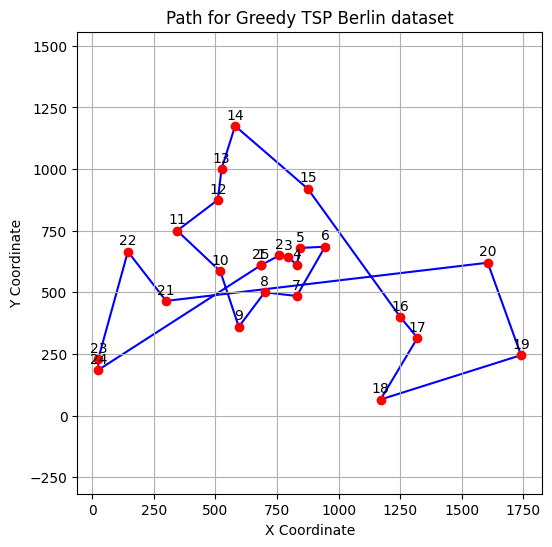

In [ ]:
# Reorder the coordinates based on the path
ordered_coordinates = berlin52_24_4[path]

# Visualize the path for Berlin dataset
plot_tsp_path(ordered_coordinates, path=np.arange(len(ordered_coordinates)), title='Path for Greedy TSP Berlin dataset')

**ST Dataset**

In [ ]:
print("Experiment on ST dataset:\n")

path2, dist2 = greedy_experiment(st70_24_4, distance_matrix_st)

Experiment on ST dataset:


Processing city 0 with coordinates [93. 54.]
Time elapsed: 0.0003437995910644531
Distance for this city: 627.7227296558337
Path for this city: [0, 12, 9, 3, 2, 19, 20, 4, 10, 15, 6, 17, 16, 7, 18, 14, 22, 13, 8, 11, 21, 1, 5, 23, 0]

Processing city 1 with coordinates [20. 18.]
Time elapsed: 0.0003459453582763672
Distance for this city: 610.1528121975862
Path for this city: [1, 5, 19, 2, 20, 3, 9, 12, 0, 15, 6, 17, 16, 7, 18, 14, 22, 13, 8, 11, 21, 23, 4, 10, 1]

Processing city 2 with coordinates [44. 33.]
Time elapsed: 0.00031304359436035156
Distance for this city: 650.158918511709
Path for this city: [2, 19, 20, 3, 9, 12, 0, 15, 6, 17, 16, 7, 18, 14, 22, 13, 8, 11, 21, 1, 5, 4, 10, 23, 2]

Processing city 3 with coordinates [63. 36.]
Time elapsed: 0.0005950927734375
Distance for this city: 627.5453705740348
Path for this city: [3, 9, 12, 0, 15, 6, 17, 16, 7, 18, 14, 22, 13, 8, 11, 21, 19, 2, 20, 4, 10, 1, 5, 23, 3]

Processing city 4 with coordinates [77.

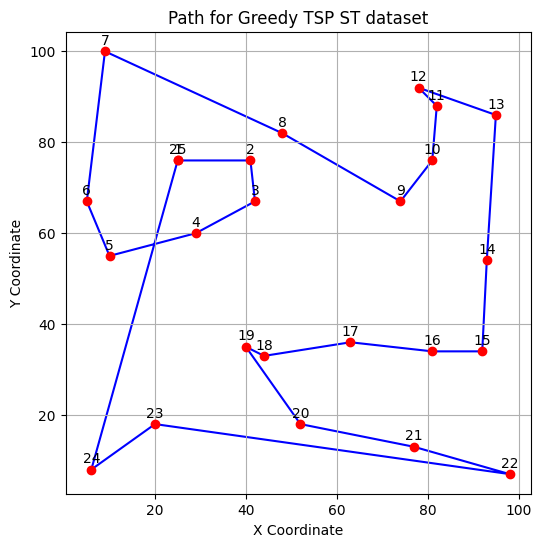

In [ ]:
# Reorder the coordinates based on the path
ordered_coordinates2 = st70_24_4[path2]

# Visualize the path for Berlin dataset
plot_tsp_path(ordered_coordinates2, path=np.arange(len(ordered_coordinates2)), title='Path for Greedy TSP ST dataset')

**Observations:**
- The Greedy Algorithm has been run starting from cities 0 to 9 and each time, the execution time is calculated.
- Note that there is **no randomness** in the greedy algorithm and thus the same path should be found each time if run starting from all 24 cities.
- After executing ten times, we observe that the execution time for the Berlin dataset is **0.00259** seconds and the average for the ST dataset is **0.00295** seconds.
- The Berlin dataset found a feasible path which is not the optimal one. This is because the best shortest path starts from city 20, which is not included if we only run 10 first cities.
- The ST dataset found the same path that was found when running all 24 cities. This is because the optimal path starts with city 8, which is included in the first 10 cities.


### Simulated Annealing ✅

**Berlin Dataset**

In [ ]:
# run simulated annealing on berlin dataset

sum_times = 0
avg_times = 0
sum_distances = 0
avg_distances = 0

overall_distance = float('inf')
overall_temp = 0
overall_costs = []
overall_tour = []
overall_time = 0

for i in range(10):
  print("Run", i+1)

  start_time = time.time()

  initial_temperature = get_initial_temperature(distance_matrix_berlin)
  best_tour, best_distance, best_temp, best_costs = simulated_annealing(distance_matrix_berlin, initial_temp=initial_temperature, cooling_rate=0.995, max_iterations=100)

  end_time = time.time()
  elapsed_time = end_time - start_time
  sum_times += elapsed_time
  sum_distances += best_distance

  # get the vest dist, temp, tour and cost for all 10 iterations
  if best_distance < overall_distance:
    overall_distance = best_distance
    overall_temp = best_temp
    overall_costs = best_costs
    overall_tour = best_tour
    overall_time = elapsed_time

  # print
  print("\nInitial temperature:", initial_temperature)
  print("Best tour:", best_tour)
  print("Best distance:", best_distance)
  print("Best temperature:", best_temp)
  print("Best costs:", best_costs)
  print("Time elapsed:", elapsed_time)
  print()

avg_times = sum_times/10
avg_distances = sum_distances/10
print("Average execution time: ", avg_times)
print("Average best distance:", avg_distances)

Run 1
Average energy lost is: 246.25151563667757

Initial temperature: 690.4087876690807
Best tour: [ 7 21 14 15  1  4 17 20 11  5  9 10 23  8 12  3 22 13 19 16  6  0  2 18]
Best distance: 13411.01413972537
Best temperature: [690.4087876690807, 686.9567437307353, 683.5219600120816, 680.1043502120212, 676.7038284609612, 673.3203093186563, 669.953707772063, 666.6039392332027, 663.2709195370367, 659.9545649393515, 656.6547921146547, 653.3715181540814, 650.104660563311, 646.8541372604944, 643.619866574192, 640.4017672413211, 637.1997584051145, 634.013759613089, 630.8436908150235, 627.6894723609483, 624.5510249991436, 621.4282698741479, 618.3211285247771, 615.2295228821532, 612.1533752677425, 609.0926083914038, 606.0471453494467, 603.0169096226995, 600.001825074586, 597.0018159492131, 594.016806869467, 591.0467228351197, 588.091489220944, 585.1510317748393, 582.2252766159652, 579.3141502328854, 576.417579481721, 573.5354915843124, 570.6678141263908, 567.8144750557589, 564.9754026804801, 562

In [ ]:
# print the best one
print("Berlin Dataset:")
print("Best tour:", overall_tour)
print("Best distance:", overall_distance)
print("Best temperature:", overall_temp)
print("Best costs:", overall_costs)
print("Best execution time:", avg_times)

Berlin Dataset:
Best tour: [13 11 18 19 23  2  7 15  3 22 12 20  6 10 16  1  9  4  0  5  8 17 21 14]
Best distance: 10448.670578907597
Best temperature: [810.9976253481984, 806.9426372214574, 802.9079240353501, 798.8933844151734, 794.8989174930975, 790.924422905632, 786.9698007911038, 783.0349517871483, 779.1197770282125, 775.2241781430714, 771.348057252356, 767.4913169660942, 763.6538603812638, 759.8355910793575, 756.0364131239608, 752.256231058341, 748.4949499030492, 744.752475153534, 741.0287127777663, 737.3235692138775, 733.6369513678081, 729.968766610969, 726.3189227779142, 722.6873281640246, 719.0738915232045, 715.4785220655884, 711.9011294552605, 708.3416238079842, 704.7999156889443, 701.2759161104996, 697.7695365299471, 694.2806888472974, 690.8092854030609, 687.3552389760456, 683.9184627811653, 680.4988704672595, 677.0963761149233, 673.7108942343486, 670.3423397631769, 666.9906280643611, 663.6556749240393, 660.3373965494192, 657.035709566672, 653.7505310188387, 650.481778363744

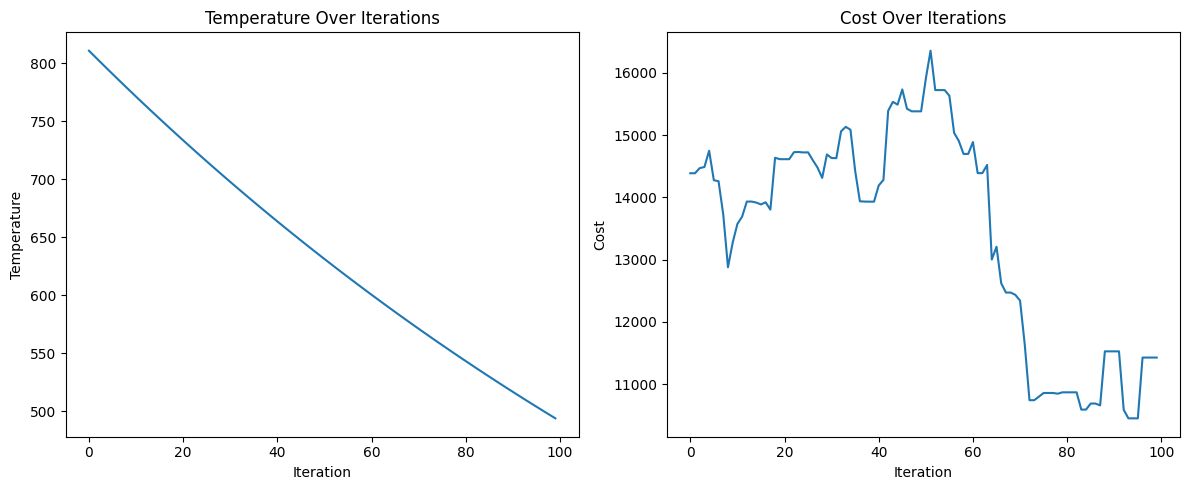

In [ ]:
# plot the best one
plot_temperature_and_cost(overall_temp, overall_costs)

**ST Dataset**

In [ ]:
# run simulated annealing on berlin dataset

sum_times = 0
avg_times = 0
sum_distances = 0
avg_distances = 0

overall_distance = float('inf')
overall_temp = 0
overall_costs = []
overall_tour = []
overall_time = 0

for i in range(10):
  print("Run", i+1)

  start_time = time.time()

  initial_temperature = get_initial_temperature(distance_matrix_st)
  best_tour, best_distance, best_temp, best_costs = simulated_annealing(distance_matrix_st, initial_temp=initial_temperature, cooling_rate=0.995, max_iterations=100)

  end_time = time.time()
  elapsed_time = end_time - start_time
  sum_times += elapsed_time
  sum_distances += best_distance

  # get the vest dist, temp, tour and cost for all 10 iterations
  if best_distance < overall_distance:
    overall_distance = best_distance
    overall_temp = best_temp
    overall_costs = best_costs
    overall_tour = best_tour
    overall_time = elapsed_time

  # print
  print("\nInitial temperature:", initial_temperature)
  print("Best tour:", best_tour)
  print("Best distance:", best_distance)
  print("Best temperature:", best_temp)
  print("Best costs:", best_costs)
  print("Time elapsed:", elapsed_time)
  print()

avg_times = sum_times/10
avg_distances = sum_distances/10
print("Average execution time: ", avg_times)
print("Average best distance:", avg_distances)

Run 1
Average energy lost is: 31.102929427069885

Initial temperature: 87.20245129529638
Best tour: [ 3 20  2  8 14 16 10  4  9  5 11 13 21 17 15 18 22 23  7  6  0 19  1 12]
Best distance: 964.2794241059723
Best temperature: [87.20245129529638, 86.7664390388199, 86.3326068436258, 85.90094380940766, 85.47143909036062, 85.04408189490881, 84.61886148543427, 84.19576717800709, 83.77478834211705, 83.35591440040646, 82.93913482840443, 82.52443915426241, 82.1118169584911, 81.70125787369865, 81.29275158433016, 80.8862878264085, 80.48185638727647, 80.07944710534008, 79.67904986981338, 79.28065462046432, 78.884251347362, 78.48983009062519, 78.09738094017206, 77.7068940354712, 77.31835956529383, 76.93176776746736, 76.54710892863002, 76.16437338398687, 75.78355151706694, 75.4046337594816, 75.02761059068419, 74.65247253773077, 74.27921017504212, 73.90781412416692, 73.53827505354609, 73.17058367827836, 72.80473075988697, 72.44070710608753, 72.07850357055709, 71.7181110527043, 71.35952049744078, 71.0

In [ ]:
# print the best one
print("ST Dataset:")
print("Best tour:", overall_tour)
print("Best distance:", overall_distance)
print("Best temperature:", overall_temp)
print("Best costs:", overall_costs)
print("Best execution time:", avg_times)

ST Dataset:
Best tour: [10  4 15  0  9 14 19  1 21 22  3 13  8 23 18 16 17  6  7  2  5 11 20 12]
Best distance: 870.5948256727991
Best temperature: [72.15975375582181, 71.7989549870427, 71.4399602121075, 71.08276041104696, 70.72734660899172, 70.37370987594676, 70.02184132656703, 69.67173211993419, 69.32337345933452, 68.97675659203784, 68.63187280907765, 68.28871344503226, 67.9472698778071, 67.60753352841806, 67.26949586077598, 66.9331483814721, 66.59848263956474, 66.26549022636691, 65.93416277523507, 65.60449196135889, 65.2764695015521, 64.95008715404434, 64.62533671827411, 64.30221003468274, 63.98069898450933, 63.66079548958678, 63.34249151213885, 63.02577905457815, 62.71065015930526, 62.397096908508736, 62.08511142396619, 61.77468586684636, 61.46581243751213, 61.158483375324565, 60.852690958447944, 60.5484275036557, 60.24568536613742, 59.94445693930673, 59.6447346546102, 59.34651098133715, 59.049778426430464, 58.754529534298314, 58.460756886626825, 58.16845310219369, 57.8776108366827

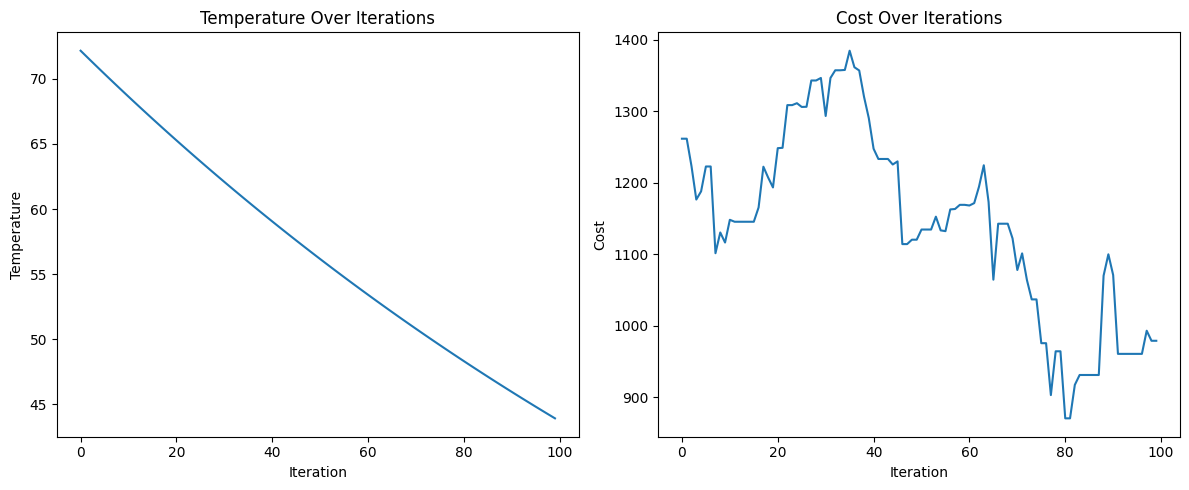

In [ ]:
# plot the best one
plot_temperature_and_cost(overall_temp, overall_costs)

**Observations:**

- For both datasets we don't see the trend of the temperature over iterations as it was only run for 100 iterations.
- For both datasets, the best tour was not found. This is again because too little iterations were used.
- There is a gradual descent of the cost with increasing iterations, showing that the cost is decreasing and solutions are improving.

Running on larger iterations should yield a better optimal route as we will see in the Bonus section.

### Genetic Algorithm ✅

In [ ]:
def genetic_experiment(distance_matrix, city_coordinates, num_runs=10, num_generations=100, pop_size=100,
                       crossover_rate=0.8, mutation_rate=0.05, elite_percent=0.02, selection_type='tournament',
                       tournament_size=3):
    """
    Conduct experiments with the Genetic Algorithm on a given dataset.

    Parameters:
    - distance_matrix: ndarray, distance matrix for the cities.
    - city_coordinates: ndarray, coordinates of the cities.
    - num_runs: int, number of independent runs of the experiment.
    - num_generations: int, number of generations for each GA run.
    - pop_size: int, size of the population.
    - crossover_rate: float, crossover rate.
    - mutation_rate: float, mutation rate.
    - elite_percent: float, percentage of elites to retain.
    - selection_type: str, type of selection ('tournament' or 'roulette').
    - tournament_size: int, size of tournament for selection.

    Returns:
    - avg_best_cost: float, average best path cost across runs.
    - avg_execution_time: float, average execution time across runs.
    - best_solution: ndarray, best solution found across all runs.
    - best_cost: float, cost of the best solution.
    - avg_distances: list, average distances over generations for the best run.
    - best_distances: list, best distances over generations for the best run.
    """
    best_overall_cost = float('inf')
    best_solution = None
    avg_best_cost = 0
    avg_execution_time = 0
    best_avg_distances = None
    best_best_distances = None

    for run in range(num_runs):
        start_time = time.time()

        # Run the Genetic Algorithm
        best_tour, best_distance, avg_distances, best_distances = genetic_algorithm(
            distance_matrix,
            pop_size=pop_size,
            num_generations=num_generations,
            crossover_rate=crossover_rate,
            mutation_rate=mutation_rate,
            elite_percent=elite_percent,
            selection_type=selection_type,
            tournament_size=tournament_size,
        )

        end_time = time.time()
        elapsed_time = end_time - start_time

        # Update averages
        avg_best_cost += best_distance
        avg_execution_time += elapsed_time

        # Check if this run produced the best solution
        if best_distance < best_overall_cost:
            best_overall_cost = best_distance
            best_solution = best_tour
            best_avg_distances = avg_distances
            best_best_distances = best_distances

    # Compute averages
    avg_best_cost /= num_runs
    avg_execution_time /= num_runs

    return avg_best_cost, avg_execution_time, best_solution, best_overall_cost, best_avg_distances, best_best_distances


In [ ]:
# Experiment on berlin52_24_4
print("Experiment on Berlin dataset:")
avg_cost_berlin, avg_time_berlin, best_solution_berlin, best_cost_berlin, avg_distances_berlin, best_distances_berlin = genetic_experiment(
    distance_matrix_berlin, berlin52_24_4
)
print(f"Average Best Path Cost: {avg_cost_berlin}")
print(f"Average Execution Time: {avg_time_berlin} seconds")
print(f"Best Path Cost: {best_cost_berlin}")

Experiment on Berlin dataset:
Average Best Path Cost: 6182.169565703078
Average Execution Time: 1.7486603260040283 seconds
Best Path Cost: 5963.256274508137


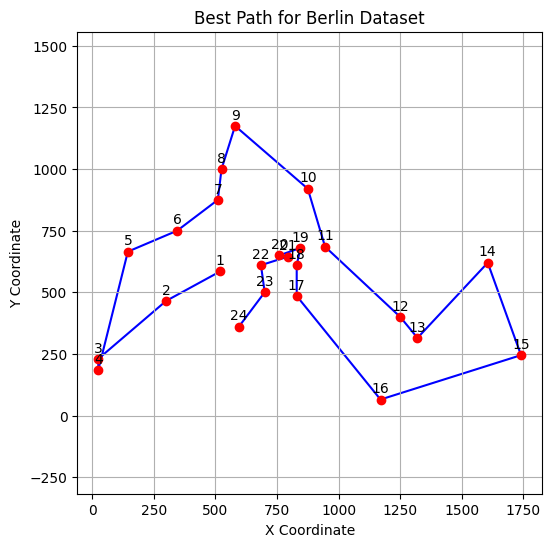

In [ ]:
# Visualize the best path
ordered_coordinates_berlin = berlin52_24_4[best_solution_berlin]
plot_tsp_path(ordered_coordinates_berlin, title="Best Path for Berlin Dataset")

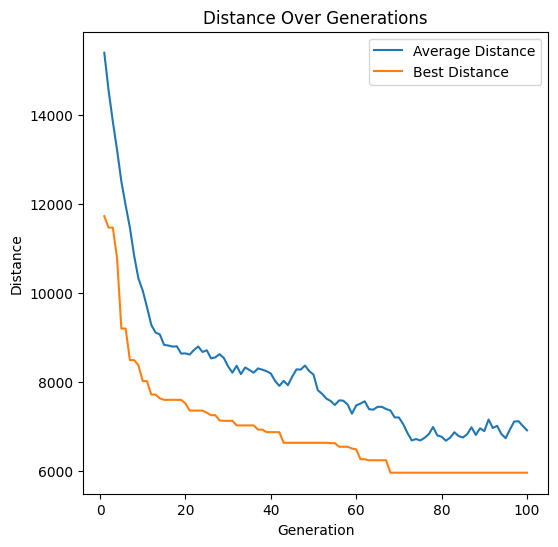

In [ ]:
# Plot fitness convergence
plot_fitness_over_generations(avg_distances_berlin, best_distances_berlin)

In [ ]:
# Experiment on st70_24_4
print("\nExperiment on ST dataset:")
avg_cost_st, avg_time_st, best_solution_st, best_cost_st, avg_distances_st, best_distances_st = genetic_experiment(
    distance_matrix_st, st70_24_4
)
print(f"Average Best Path Cost: {avg_cost_st}")
print(f"Average Execution Time: {avg_time_st} seconds")
print(f"Best Path Cost: {best_cost_st}")


Experiment on ST dataset:
Average Best Path Cost: 505.61137607091285
Average Execution Time: 1.732801127433777 seconds
Best Path Cost: 477.12672170763915


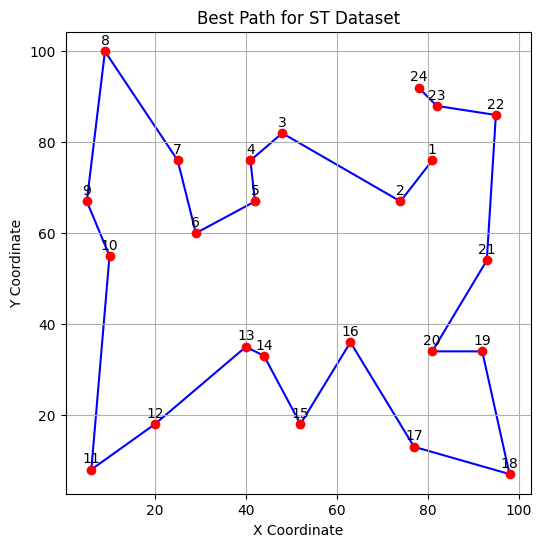

In [ ]:
# Visualize the best path
ordered_coordinates_st = st70_24_4[best_solution_st]
plot_tsp_path(ordered_coordinates_st, title="Best Path for ST Dataset")

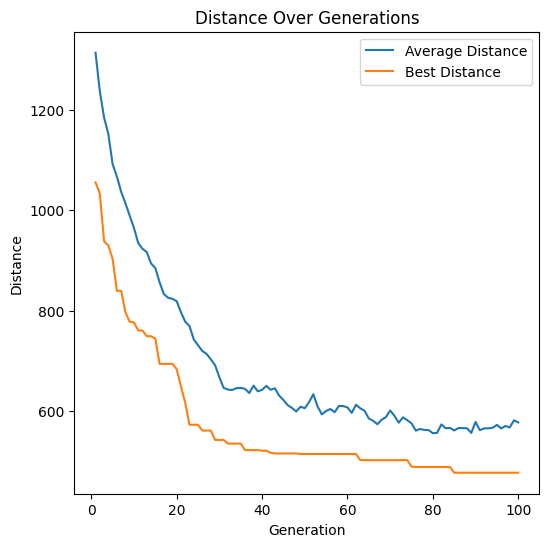

In [ ]:
# Plot fitness convergence
plot_fitness_over_generations(avg_distances_st, best_distances_st)

**Observations:**

- The Genetic Algorithm consistently improved the path cost over generations, achieving the best path cost of **5963.25** for the Berlin dataset and **477.12** for the ST dataset.
- Average execution times were similar for both datasets, around **1.7 seconds**, showing efficiency in computation.
- The algorithm effectively balances exploration and exploitation, resulting in near-optimal solutions across multiple runs.
- Parameter tuning, such as increasing generations, could further enhance solution quality at the expense of runtime.

### 2.2. Results Discussion ✅

Conduct a thorough analysis of the algorithmic performance on the `berlin52_24_4` and `st70_24_4` datasets, addressing the following key points:

1. **Performance Comparison**:

   - Examine the **average best path costs** achieved by each algorithm on both datasets. Identify which algorithm most closely approximates the optimal solution.
   - Discuss any observed performance differences between the datasets. Consider whether the size or complexity of a dataset influences the results.

2. **Consistency**:

   - Assess the variability of results across multiple runs for each algorithm. Determine whether the results are consistent or if there are significant fluctuations between executions.
   - Note any trends or patterns in the solutions, such as whether an algorithm consistently yields higher costs or achieves faster execution times.

3. **Efficiency**:

   - Compare the **average execution times** of the algorithms. Identify the fastest and slowest algorithms, and consider any trade-offs between computational efficiency and solution quality.

4. **Strengths and Weaknesses**:

   - Highlight the strengths of each algorithm, such as speed, accuracy, or reliability.
   - Discuss any limitations or weaknesses encountered during the experiments, including sensitivity to initialization, propensity to get trapped in local optima, or high computational demands.

5. **Insights and Implications**:

   - Summarize the key insights gained from the analysis. Consider what the results suggest about each algorithm's suitability for solving the TSP.
   - Offer observations on how algorithm performance might scale with larger datasets.

Enhance your discussion with tables, charts, or visualizations to clarify and emphasize your analysis.

--- **Summary of results** ---



In [ ]:
import pandas as pd

# Data preparation
data = [
    {
        "Algorithm": "Greedy 10 cities",
        "Dataset": "Berlin",
        "Average Execution Time": 0.00259,
        "Average Best Distance": 7369,
        "Best Distance": 7149,
    },
    {
        "Algorithm": "Greedy 10 cities",
        "Dataset": "ST",
        "Average Execution Time": 0.00295,
        "Average Best Distance": 619,
        "Best Distance": 565,
    },
    {
        "Algorithm": "Simulated Annealing",
        "Dataset": "Berlin",
        "Average Execution Time": 0.0106,
        "Average Best Distance": 12137,
        "Best Distance": 10448,
    },
    {
        "Algorithm": "Simulated Annealing",
        "Dataset": "ST",
        "Average Execution Time": 0.01135,
        "Average Best Distance": 1018,
        "Best Distance": 870,
    },
    {
        "Algorithm": "Genetic Algorithm",
        "Dataset": "Berlin",
        "Average Execution Time": 1.7486,
        "Average Best Distance": 6182,
        "Best Distance": 5963,
    },
    {
        "Algorithm": "Genetic Algorithm",
        "Dataset": "ST",
        "Average Execution Time": 1.7328,
        "Average Best Distance": 505,
        "Best Distance": 477,
    },
]


df = pd.DataFrame(data)
print(df)
print()
df.style.format({"Average Execution Time": "{:.5f}", "Average Best Distance": "{:.0f}", "Best Distance": "{:.0f}"})


             Algorithm Dataset  Average Execution Time  Average Best Distance  \
0     Greedy 10 cities  Berlin                 0.00259                   7369   
1     Greedy 10 cities      ST                 0.00295                    619   
2  Simulated Annealing  Berlin                 0.01060                  12137   
3  Simulated Annealing      ST                 0.01135                   1018   
4    Genetic Algorithm  Berlin                 1.74860                   6182   
5    Genetic Algorithm      ST                 1.73280                    505   

   Best Distance  
0           7149  
1            565  
2          10448  
3            870  
4           5963  
5            477  



,Algorithm,Dataset,Average Execution Time,Average Best Distance,Best Distance
0,Greedy 10 cities,Berlin,0.00259,7369,7149
1,Greedy 10 cities,ST,0.00295,619,565
2,Simulated Annealing,Berlin,0.01060,12137,10448
3,Simulated Annealing,ST,0.01135,1018,870
4,Genetic Algorithm,Berlin,1.74860,6182,5963
5,Genetic Algorithm,ST,1.73280,505,477


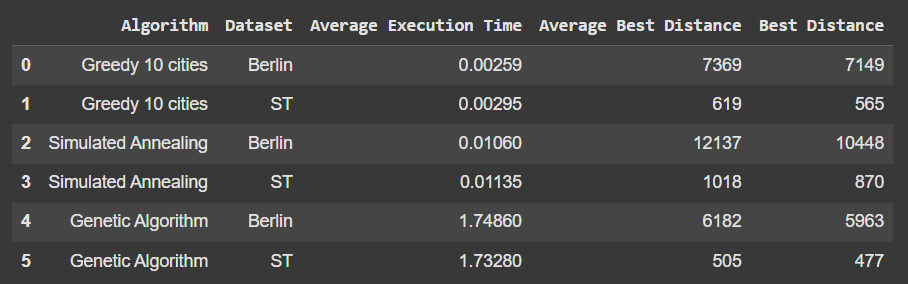

*NOTE: The image above is the output of `df.style.format({"Average Execution Time": "{:.5f}", "Average Best Distance": "{:.0f}", "Best Distance": "{:.0f}"})` in the previous cell. We placed a screenshot of it here in case it's not viewable in your code editor (e.g. VSCode).*

Overall Fastest: Greedy Algorithm<br>
Overall Best distance: Genetic Algorithm

#### **1. Performance Comparison**
- The Greedy Algorithm provided solutions quickly but was often limited to suboptimal results due to its *short-sighted approach*. It committed to local decisions without exploring alternatives, which led to higher overall costs compared to the Genetic Algorithm and Simulated Annealing.
- Simulated Annealing consistently achieved the low costs, demonstrating its effectiveness in finding near-optimal or optimal solutions by balancing exploration and exploitation over iterations.
- The Genetic Algorithm showed the strongest ability to explore a variety of solutions through crossover and mutation, achieving lower costs than both the Greedy Algorithm and the Simulated Annealing.

The Genetic Algorithm is therefore the best one in terms of performance.



#### **2. Consistency**
- The Greedy Algorithm exhibited the highest consistency as it is deterministic and provides similar results across runs. However, this consistency is at the expense of quality, as it is prone to being trapped in local optima.
- Simulated Annealing demonstrated moderate consistency, with controlled randomness during the early stages of the cooling schedule reducing variability and producing results that were more consistent than the Genetic Algorithm but less consistent than the Greedy Algorithm.
- The Genetic Algorithm introduced variability in results due to its stochastic operations like mutation and crossover, leading to different outcomes across runs depending on the random seed and population diversity.

#### **3. Efficiency**
- The Greedy Algorithm was the most efficient in terms of speed, as it does not rely on iterative processes or extensive computation. It is best suited for scenarios where quick results are required.
- Simulated Annealing achieved a good balance between computation time and solution quality but was slower than the Greedy Algorithm, especially for small numbers of iterations.
- The Genetic Algorithm was computationally more expensive due to the need to manage a population, evaluate fitness, and perform genetic operations. Its efficiency depends heavily on the size of the population and the number of generations.

#### **4. Strengths and Weaknesses**
- The Greedy Algorithm's primary strength lies in its simplicity, speed, and ease of implementation. However, its main weakness is its inability to backtrack or explore, making it prone to local optima.
- Simulated Annealing's strength is its capability to escape local optima and converge toward a global solution, making it highly effective for global optimization problems. However, it requires careful tuning of the cooling schedule, and its efficiency is lower than the Greedy Algorithm for small iteration counts.
- The Genetic Algorithm is highly robust for complex optimization tasks, with strengths including its ability to avoid local optima due to population diversity and stochastic operations. Its weaknesses include computational expense and sensitivity to hyperparameters like mutation rate and population size.

#### **5. Insights and Implications**
- The Greedy Algorithm is ideal for problems where speed is prioritized over solution quality, especially in deterministic and straightforward problem spaces.
- Simulated Annealing excels in global optimization tasks, provided sufficient iterations are allowed. Its gradual reduction in temperature ensures systematic improvement in solutions.
- The Genetic Algorithm is a strong choice for exploratory tasks where the solution space is large and diverse. It can effectively balance exploration and exploitation, making it suitable for problems with multiple optima.

Overall, the choice of algorithm depends on the problem's constraints and priorities. For rapid solutions, the Greedy Algorithm is preferred. When global optimization is crucial, Simulated Annealing is the most suitable choice. For a more thorough exploration of solutions, the Genetic Algorithm is effective.

<hr/>

## 3 Optional Bonus Question

This question is optional and offers up to 5 bonus points for executing your program on the full datasets, `berlin52` and `st70`.

Grading Rubric:

- **5 points**: Both Simulated Annealing (SA) and Genetic Algorithm (GA) achieve the optimal solution for both datasets.
- **4 points**: Both SA and GA achieve solutions within 5% of the optimal for both datasets.
- **3 points**: Both SA and GA outperform greedy algorithms for both datasets.
- **2 points**: Either SA or GA achieves the optimal solution for both datasets.
- **1 point**: Either SA or GA outperforms greedy algorithms for both datasets.

Include the necessary source code below to demonstrate your results. The base implementation of SA and GA should remain consistent with the main part of this assignment, with only input parameters varying.

In [ ]:
URL = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/main/assignments-data/a4/'

berlin52 = read_tsp(URL + 'berlin52.tsp')
st70 = read_tsp(URL + 'st70.tsp')

In [ ]:
# Berlin dataset
matrix_berlin_bonus = get_distance_matrix(berlin52)

# ST dataset
matrix_st_bonus = get_distance_matrix(st70)

### **Greedy Algorithm**

Berlin

In [ ]:
# Get Greedy algorithm results for Berlin

path, dist = greedy_tsp(berlin52, matrix_berlin_bonus)

# print
print("Shortest path: ", path)
print("Shortest distance: ", dist)

Shortest path:  [39, 37, 36, 38, 35, 34, 33, 43, 45, 47, 23, 4, 14, 5, 3, 24, 11, 27, 26, 25, 46, 12, 13, 51, 10, 50, 32, 42, 9, 8, 7, 40, 18, 44, 31, 48, 0, 21, 30, 17, 2, 16, 20, 22, 19, 49, 15, 28, 29, 41, 6, 1, 39]
Shortest distance:  8182.1915557256725


ST

In [ ]:
# Get Greedy algorithm results for ST

path, dist = greedy_tsp(st70, matrix_st_bonus)

# print
print("Shortest path: ", path)
print("Shortest distance: ", dist)

Shortest path:  [41, 17, 3, 1, 6, 31, 2, 7, 27, 25, 48, 54, 18, 23, 14, 56, 62, 21, 58, 37, 68, 30, 12, 28, 69, 34, 22, 0, 35, 15, 46, 36, 57, 49, 9, 51, 59, 11, 20, 33, 32, 53, 61, 47, 66, 55, 64, 50, 10, 63, 4, 52, 65, 5, 40, 42, 16, 8, 39, 60, 38, 44, 24, 45, 26, 67, 43, 29, 19, 13, 41]
Shortest distance:  761.6890898866324


### **Simulated Annealing**

Berlin

In [ ]:
# Get simulated annealing results for Berlin

# loop until cost is within 5% of optimal solution
best_distance = 10000
while best_distance > 7919:
  init = get_initial_temperature(matrix_berlin_bonus)
  best_tour, best_distance, best_temp, best_costs = simulated_annealing(matrix_berlin_bonus, initial_temp=init, cooling_rate=0.995, max_iterations=8000)

# print
print("Initial temperature:", init)
print("Best tour:", best_tour)
print("Best distance:", best_distance)
print("Best temperature:", best_temp)
print("Best costs:", best_costs)

Initial temperature: 918.0310847631456
Best tour: [42 32 50 11 10 51 13 12 46 25 26 27 24  3  5 14  4 23 47 37 36 39 38 35
 34 33 43 45 15 28 49 19 22 29  1  6 41 16  2 17 20 30 21  0 48 31 44 18
 40  7  8  9]
Best distance: 7876.015394216741
Best temperature: [70.61835263774677, 70.26526087455804, 69.91393457018525, 69.56436489733431, 69.21654307284764, 68.87046035748341, 68.52610805569599, 68.18347751541751, 67.84256012784041, 67.50334732720121, 67.1658305905652, 66.83000143761238, 66.49585143042432, 66.16337217327221, 65.83255531240584, 65.50339253584382, 65.17587557316459, 64.84999619529877, 64.52574621432228, 64.20311748325067, 63.88210189583441, 63.56269138635524, 63.24487792942347, 62.92865353977635, 62.614010272077465, 62.30094022071708, 61.989435519613494, 61.679488342015425, 61.37109090030535, 61.06423544580382, 60.7589142685748, 60.45511969723192, 60.15284409874576, 59.852079878252034, 59.552819478860776, 59.25505538146647, 58.95878010455914, 58.66398620403634, 58.3706662730

Within 5% of the optimal solution means a cost **<=7919**. <br>
The optimal solution for Berlin52 is 7542. I have achieved a cost of **7876** for Simulated Annealing, which is within 5% of the optimal solution.

ST

In [ ]:
# Get simulated annealing results for ST

# loop until cost is within 5% of optimal solution
best_distance = 10000
while best_distance > 708:
  init = get_initial_temperature(matrix_st_bonus)
  best_tour, best_distance, best_temp, best_costs = simulated_annealing(matrix_st_bonus, initial_temp=init, cooling_rate=0.995, max_iterations=8000)

# print
print("Initial temperature:", init)
print("Best tour:", best_tour)
print("Best distance:", best_distance)
print("Best temperature:", best_temp)
print("Best costs:", best_costs)

Initial temperature: 84.18147553283926
Best tour: [23 14 56 62 65 21 58 37 30 68 34 69 12 28 35  0 22 46 15 36 57 49 50 55
 64 63 10 47 66 53 61 38 24 44 45 26 39 60  8 67 43 42 16 33 20 11 32 59
 51  9  4 52  5 40 41 17  3 31  2 13 29 19 27  7 25 48 54 18  6  1]
Best distance: 704.631216719531
Best temperature: [84.18147553283926, 83.76056815517506, 83.34176531439918, 82.92505648782719, 82.51043120538806, 82.09787904936111, 81.68738965411431, 81.27895270584374, 80.87255794231451, 80.46819515260295, 80.06585417683993, 79.66552490595573, 79.26719728142595, 78.87086129501883, 78.47650698854373, 78.08412445360102, 77.69370383133301, 77.30523531217635, 76.91870913561547, 76.5341155899374, 76.15144501198772, 75.77068778692778, 75.39183434799314, 75.01487517625317, 74.6398008003719, 74.26660179637004, 73.89526878738819, 73.52579244345125, 73.158163481234, 72.79237266382783, 72.4284108005087, 72.06626874650615, 71.70593740277363, 71.34740771575976, 70.99067067718096, 70.63571732379505, 70.282

Within 5% of the optimal solution means a cost **<=708**. <br>
The optimal solution for ST70 is 675. I have achieved a cost of **704** for Simulated Annealing, which is within 5% of the optimal solution.

### **Genetic Algorithm**

Berlin

In [ ]:
# Get results of GA on berlin

best_solution, best_distance, average_distance_history, best_distance_history = genetic_algorithm(matrix_berlin_bonus,
pop_size=200, num_generations=200, crossover_rate=0.8,
mutation_rate=0.1, elite_percent=0.02, selection_type='tournament')

# print results
print("Best solution:", best_solution)
print("Best distance:", best_distance)
print("Average distance history:", average_distance_history)
print("Best distance history:", best_distance_history)

Best solution: [17 30  2 16 20  1  6 41 29 22 19 49 28 15 43 45 24  3 23 47  4 14 44 40
 18  7  8  9 42 50 11 27 26 25 46 12 13 51 10 32  5 39 37 36 35 38 48 34
 33 31  0 21]
Best distance: 9097.981787977824
Average distance history: [29956.117650243592, 28721.531478915735, 27761.193318850124, 26997.844333056364, 26466.17236890405, 26058.953896940326, 25592.4172060999, 25016.711381286885, 24509.620997993647, 24018.828302675494, 23896.18195261223, 23345.752911849282, 23039.997952171267, 22539.76942252418, 22037.08243558921, 21485.38677136365, 21344.204910895485, 21013.639341802365, 20661.983836931995, 20671.349250144718, 20292.464546821793, 20021.83235722403, 19795.26758592147, 19613.23509123207, 19417.448523842166, 19194.817856850907, 19029.472229814226, 18902.379601380097, 18584.231526723943, 18395.225875861426, 17969.129699037792, 17547.277015578882, 17162.516401828514, 17038.473112024927, 17133.854404839105, 16941.175615723085, 16657.113566585616, 16418.867534292407, 16318.301919181

ST

In [ ]:
# Get results of GA on ST

best_solution, best_distance, average_distance_history, best_distance_history = genetic_algorithm(matrix_st_bonus,
pop_size=200, num_generations=200, crossover_rate=0.8,
mutation_rate=0.1, elite_percent=0.02, selection_type='tournament')

# print results
print("Best solution:", best_solution)
print("Best distance:", best_distance)
print("Average distance history:", average_distance_history)
print("Best distance history:", best_distance_history)

Best solution: [ 8 67 19 13 48 54 25  1 18  3 41 20 33 16 42 52 40  5 32 11 51 59  9  4
 57 36 15 55 61 53 47 10 66 63 64 50 49 46  0 12 68 69 23 14 56 58 37 62
 21 22 35 28 34 30 65 17  6  2 27  7 31 29 43 26 45 60 44 24 38 39]
Best distance: 1089.616116972437
Average distance history: [3655.9160042171634, 3503.60389233761, 3390.973469597624, 3285.10186219263, 3196.8045336588243, 3105.9523787507055, 3047.9259103261775, 2983.2778203868343, 2930.8953045909966, 2888.8296981617727, 2856.068579223117, 2810.7338068633585, 2790.044524506836, 2754.264082292908, 2719.159292134704, 2691.8408010630724, 2631.6011538115326, 2595.9722094415542, 2563.2725295495966, 2537.4758347329694, 2546.6719133244037, 2514.879405924411, 2491.938166825227, 2437.837483243063, 2391.6085316278386, 2359.0712873018597, 2317.15602450229, 2281.783344008902, 2237.7886837815736, 2196.5367857110264, 2174.454800020355, 2139.838746027576, 2134.4441425689993, 2118.779644520669, 2118.669895881279, 2105.7860461063833, 2106.00814

### **Summary of Results**

**Optimal**
```
Berlin: 7542
ST: 675
```

**Greedy**
```
Berlin Shortest distance:  8182.1915557256725
ST Shortest distance:  761.6890898866324
```

**SA**
```
Berlin Best distance: 7876.015394216741
ST Best distance: 704.631216719531
```

**GA**
```
Berlin Best distance: 9097.981787977824
ST Best distance: 1089.616116972437
```

Currently:
- SA achieves solutions within 5% of the optimal for both datasets
- SA outperforms greedy for both datasets

# Resources

**Online sources:**
- https://www.youtube.com/watch?v=GYZ_T4n3yFo
- https://medium.com/@francis.allanah/travelling-salesman-problem-using-simulated-annealing-f547a71ab3c6
- https://www.obitko.com/tutorials/genetic-algorithms/ga-basic-description.php
- https://medium.com/aimonks/traveling-salesman-problem-tsp-using-genetic-algorithm-fea640713758

**Course notes:**
- https://turcotte.xyz/teaching/csi-4106/lectures/15/slides.html
- https://turcotte.xyz/teaching/csi-4106/lectures/16/slides.html#/title-slide

**ChatGPT Transcript**
- https://chatgpt.com/share/674cc238-b46c-800b-9d63-faf707d674c1

NOTE: This notebook can also be accessed via the following Google Colab URL
- https://colab.research.google.com/drive/1YktclwTKlg1uJitxeVzjo3QkgByrIy3m?usp=sharing

**Division of tasks:**
- Kanjanokphat:
    - Implemented Greedy Algorithm and Simulated Annealing
    - Experimentation of Greedy Algorithm and Simulated Annealing
    - Bonus
- Kien:
    - Implemented Genetic Algorithm
    - Experimentation of Genetic Algorithm
- Both:
    - Analysis of Results

The tasks were split equally between the 2 students and then both students went on a meeting to verify and finalize the work.

We both went through the whole assignment together at the end to make sure we understand the use of functions and concepts applied, resolving any disagreements and suggesting enhancements. This way, we both achieved the learning outcomes.

# Evaluation Criteria

- **Overall Effort in the Report (10%)**
  
- **Greedy Algorithm Implementation (20%)**
  
- **Simulated Annealing Implementation (15%)**
  
- **Genetic Algorithm Implementation (30%)**
  
- **Execution (15%)**
  
- **Analysis of Results (10%)**

# Resources

As for previous assignments, it is crucial to cite any sections of your code that are derived from external sources such as websites, textbooks, or other materials. This includes acknowledging libraries you have used, regardless of your prior familiarity with the concepts.

The use of artificial intelligence to enhance programming productivity is increasingly common and expected to grow. While these technologies can be employed to assist with assignments, it is essential that you fully understand the evaluated concepts, as such tools will not be available during in-person assessments.

If you utilize AI assistance, meticulously document your interactions. Include the tools and their versions in your report, accompanied by a transcript of all interactions. Most AI assistants maintain records of your conversations. It is advisable to create a new conversation specifically for the assignment and reuse this thread consistently throughout your work. Ensure this conversation focuses exclusively on the assignment. Include the conversation transcript in the reference section of your Jupyter Notebook.

# Questions

- You may post questions in the Assignment topic on the Brightspace discussion forum.

- Alternatively, you can email one of the four teaching assistants. However, using the forum is strongly preferred as it allows all students to benefit from the questions and the teaching assistants' responses.